# MNIST Handwritten Digit Classifier

**Author: Jingjing Geng**

## About This Project

In this project, I trained a simple neural network to recognize handwritten digits from 0 to 9. I used TensorFlow and the MNIST dataset.

I also tested the model, looked at some correct and incorrect predictions, and made graphs to see how the model improved during training.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load the MNIST handwritten-digit dataset
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


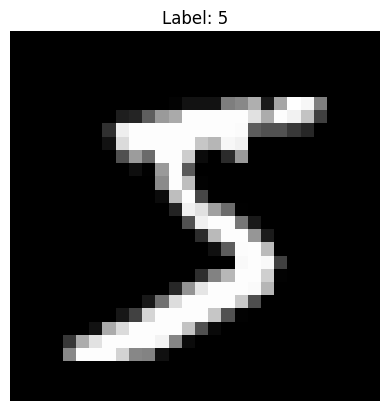

In [3]:
# Display the first training image
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [4]:
# Normalize pixel values from 0–255 to 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
# Build the neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Configure how the model will learn
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the neural network
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9261 - loss: 0.2447 - val_accuracy: 0.9662 - val_loss: 0.1062
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9685 - loss: 0.1017 - val_accuracy: 0.9718 - val_loss: 0.0954
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9777 - loss: 0.0697 - val_accuracy: 0.9762 - val_loss: 0.0799
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9833 - loss: 0.0526 - val_accuracy: 0.9780 - val_loss: 0.0799
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9871 - loss: 0.0402 - val_accuracy: 0.9798 - val_loss: 0.0728


In [7]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.0743
Test accuracy: 97.85%


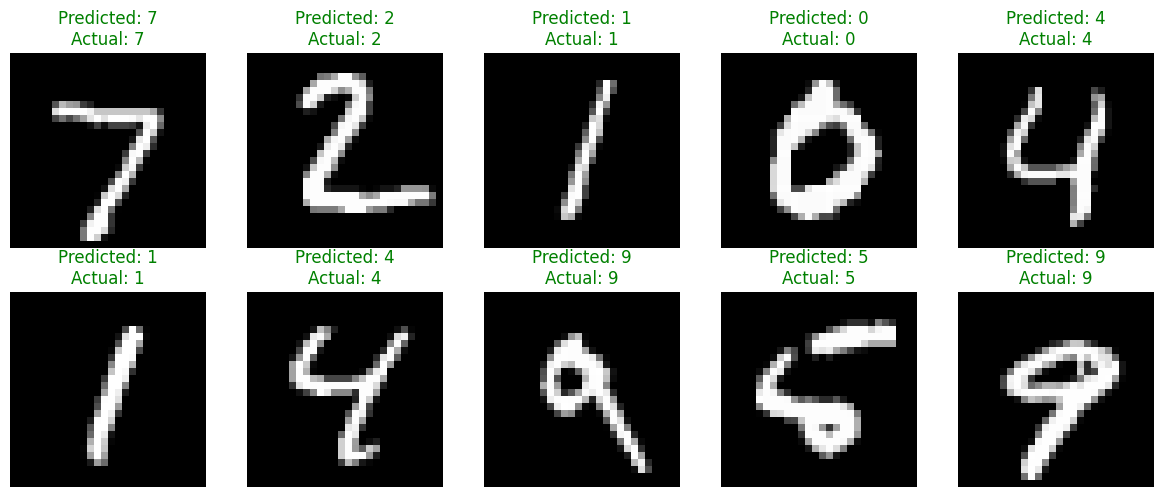

In [8]:
# Make predictions on the test images
predictions = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Display the first 10 predictions
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")

    predicted = predicted_labels[i]
    actual = y_test[i]

    color = "green" if predicted == actual else "red"
    plt.title(
        f"Predicted: {predicted}\nActual: {actual}",
        color=color
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of incorrect predictions: 215
Number of correct predictions: 9785


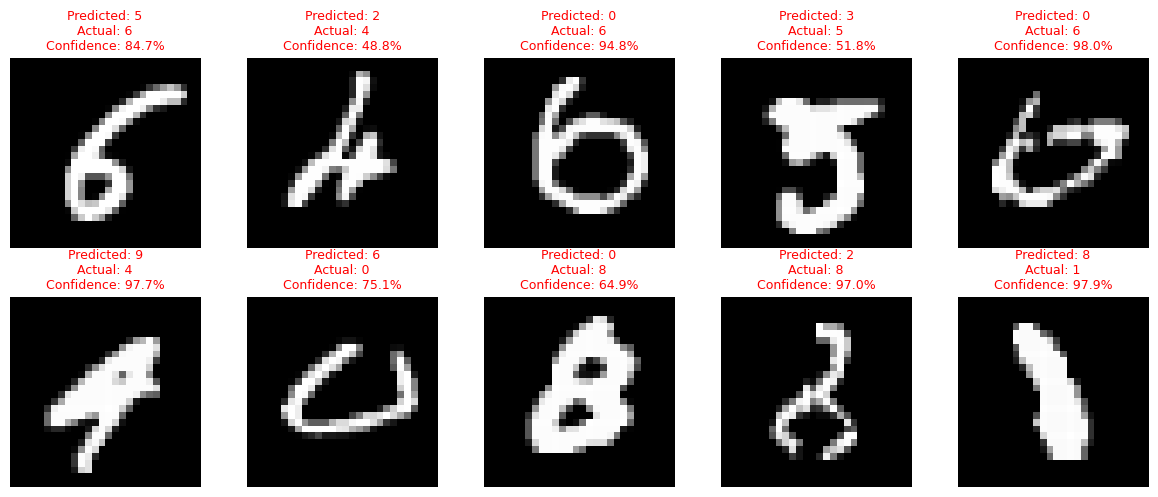

In [9]:
# Find incorrectly classified test images
incorrect_indices = np.where(predicted_labels != y_test)[0]

print("Number of incorrect predictions:", len(incorrect_indices))
print("Number of correct predictions:", len(y_test) - len(incorrect_indices))

# Display the first 10 incorrect predictions
plt.figure(figsize=(12, 5))

for i, index in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index], cmap="gray")

    predicted = predicted_labels[index]
    actual = y_test[index]
    confidence = predictions[index][predicted] * 100

    plt.title(
        f"Predicted: {predicted}\nActual: {actual}\nConfidence: {confidence:.1f}%",
        color="red",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

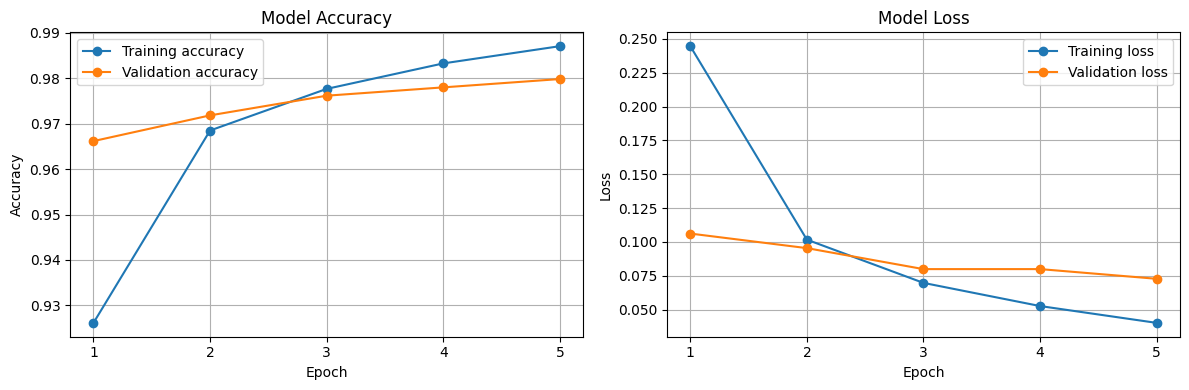

In [10]:
# Plot training history
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(12, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(epochs, history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["loss"], marker="o", label="Training loss")
plt.plot(epochs, history.history["val_loss"], marker="o", label="Validation loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Results and Conclusion

The neural network achieved **97.85% test accuracy** on 10,000 test images. It correctly classified **9,785 images** and incorrectly classified **215 images**.

The training graphs show that accuracy increased while loss decreased over five epochs. This means the model learned useful patterns from the MNIST training images.

Some incorrect predictions involved digits with unusual or ambiguous handwriting. For example, a handwritten 6 could look like a 5, and a handwritten 4 could look like a 9.

From this project, I learned that a neural network can learn from examples by adjusting its weights to reduce prediction error. I also learned the roles of input data, hidden layers, activation functions, loss, accuracy, and test data.

## References

- GeeksforGeeks: Classifying Handwritten Digits with TensorFlow
- 3Blue1Brown: *But what is a neural network?*
